In [1]:
import torch 
import torch.nn as nn
import numpy as np
from pathlib import Path
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from src.data.tabular import split_data
from src.models.Autoencoder import Autoencoder

In [2]:
digits = load_digits()
X = digits.data
X = StandardScaler().fit_transform(X)  
y = digits.target
X_train, X_val, X_test, y_train, y_val, y_test, encoder = split_data(X, y)
X_train_tensor = torch.from_numpy(X_train).float()
X_val_tensor   = torch.from_numpy(X_val).float()
X_test_tensor  = torch.from_numpy(X_test).float()

X_train_val_tensor = torch.cat([X_train_tensor, X_val_tensor], dim=0)
X_train_val = X_train_val_tensor.detach().cpu().numpy()
print("split shape",X_train.shape, X_val.shape, X_test.shape)

n_features = X_train.shape[1]

split shape (1078, 64) (360, 64) (359, 64)


In [ ]:
"""def build_hidden_dims(input_dim, latent_dim, depth):
    values = np.geomspace(input_dim, latent_dim, num=depth+2)[1:-1]
    hidden_dims = []
    previous = input_dim 
    for value in values:
        width = int(round(value))
        width = max(latent_dim + 1, width)
        width = min(previous - 1, width)

        if width <= latent_dim:
            break
        hidden_dims.append(width)
        previous = width
    return hidden_dims"""

def build_hidden_dims(input_dim, depth=1):
    if depth == 1:
        return [2 * input_dim]

    if depth == 2:
        return [2 * input_dim, input_dim]

    if depth == 3:
        return [2 * input_dim, input_dim, input_dim]

    raise ValueError("Unsupported depth")

In [18]:
def train_final_model(final_model, X_train_val_tensor, n_epoch,learning_rate):
    optimizer = torch.optim.Adam(final_model.parameters(), lr=learning_rate)
    loss_fn = nn.MSELoss()

    final_model.train()
    for epoch in range(1, n_epoch + 1):
        optimizer.zero_grad()
        x_hat, _ = final_model(X_train_val_tensor)
        loss = loss_fn(x_hat, X_train_val_tensor)
        loss.backward()
        optimizer.step()

    final_model.eval()
    with torch.no_grad():
        x_test_hat, z_test = final_model(X_test_tensor)
        test_loss = loss_fn(x_test_hat, X_test_tensor)

    return loss.item(), test_loss.item()

In [19]:
bottleneck_range = [1, 2, 4, 8, 16, 32, 62]

nonlinear_ae_errors = []
linear_ae_errors = []
pca_errors = []

input_dim = X_train_val_tensor.shape[1]
depth = 1
n_epochs = 300
activation = nn.ReLU
learning_rate = 0.001


for k in bottleneck_range:
    final_hidden_dims = build_hidden_dims(input_dim, depth)
    # ----------------- Linear Autoencoder------------- 
    linear_model = Autoencoder(
        n_features=input_dim,
        bottleneck_dim=k,
        non_linear=False,
        non_linear_function=activation,
        hidden_dims_list=final_hidden_dims
    )
     # ----------------- Non Linear Autoencoder------------- 
    nonlinear_model = Autoencoder(
        n_features=input_dim,
        bottleneck_dim=k,
        non_linear=True,
        non_linear_function=activation,
        hidden_dims_list=final_hidden_dims
    )
    # ----------------- PCA ------------- 
    pca = PCA(n_components=k)
    X_reduced = pca.fit_transform(X_train_val)
    X_recon_pca = pca.inverse_transform(X_reduced)
    pca_errors.append(np.mean((X_train_val - X_recon_pca) ** 2))

    linear_train_loss, linear_test_loss = train_final_model(
        final_model=linear_model,
        X_train_val_tensor=X_train_val_tensor,
        n_epoch=n_epochs,
        learning_rate=learning_rate

    )

    nonlinear_train_loss, nonlinear_test_loss = train_final_model(
            final_model=nonlinear_model,
            X_train_val_tensor=X_train_val_tensor,
            n_epoch=n_epochs,
            learning_rate=learning_rate
    
    )

    nonlinear_ae_errors.append(nonlinear_train_loss)
    linear_ae_errors.append(linear_train_loss)
    print(f"k={k:>3} PCA = {pca_errors[-1]:.4f},  Linear AE = {linear_ae_errors[-1]:.4f}, Non Linear AE={nonlinear_ae_errors[-1]:.4f}")

k=  1 PCA = 0.8499,  Linear AE = 0.8499, Non Linear AE=0.6541
k=  2 PCA = 0.7585,  Linear AE = 0.7585, Non Linear AE=0.4255
k=  4 PCA = 0.6153,  Linear AE = 0.6153, Non Linear AE=0.2756
k=  8 PCA = 0.4561,  Linear AE = 0.4561, Non Linear AE=0.1739
k= 16 PCA = 0.2587,  Linear AE = 0.2598, Non Linear AE=0.1023
k= 32 PCA = 0.0855,  Linear AE = 0.0874, Non Linear AE=0.0642
k= 62 PCA = 0.0000,  Linear AE = 0.0193, Non Linear AE=0.0411


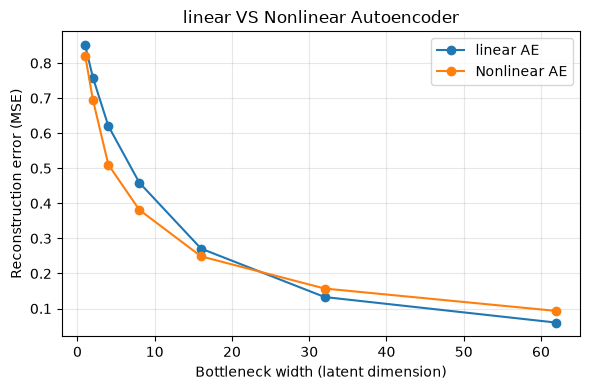

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(bottleneck_range, linear_ae_errors, marker="o", label="linear AE")
plt.plot(bottleneck_range, nonlinear_ae_errors, marker="o", label="Nonlinear AE")
plt.xlabel("Bottleneck width (latent dimension)")
plt.ylabel("Reconstruction error (MSE)")
plt.title("linear VS Nonlinear Autoencoder")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../plots/research/std_linear_vs_nonlinear_ae_loss.png", dpi=150)
plt.show()

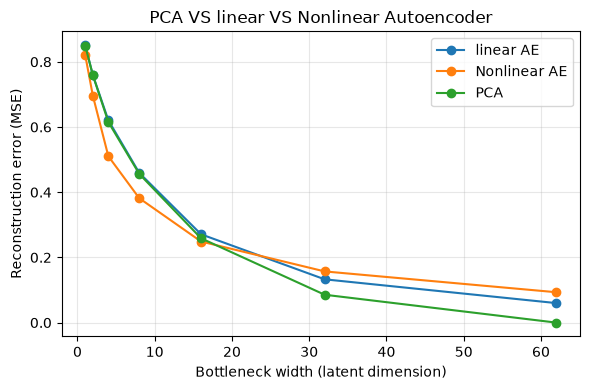

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(bottleneck_range, linear_ae_errors, marker="o", label="linear AE")
plt.plot(bottleneck_range, nonlinear_ae_errors, marker="o", label="Nonlinear AE")
plt.plot(bottleneck_range, pca_errors, marker="o", label="PCA")
plt.xlabel("Bottleneck width (latent dimension)")
plt.ylabel("Reconstruction error (MSE)")
plt.title("PCA VS linear VS Nonlinear Autoencoder")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../plots/research/pca_vs_std_linear_vs_nonlinear_ae_loss.png", dpi=150)
plt.show()

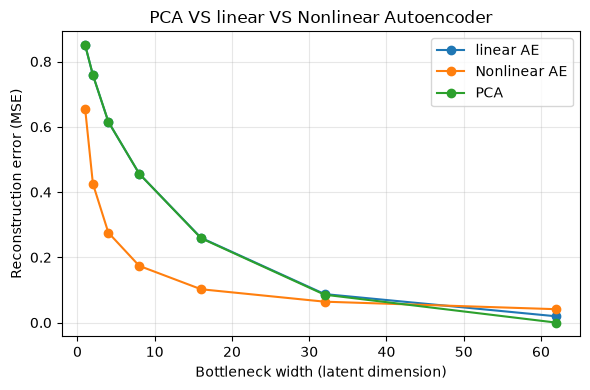

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(bottleneck_range, linear_ae_errors, marker="o", label="linear AE")
plt.plot(bottleneck_range, nonlinear_ae_errors, marker="o", label="Nonlinear AE")
plt.plot(bottleneck_range, pca_errors, marker="o", label="PCA")
plt.xlabel("Bottleneck width (latent dimension)")
plt.ylabel("Reconstruction error (MSE)")
plt.title("PCA VS linear VS Nonlinear Autoencoder")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()